# 07 Missing Data and Feature Selection

Missing-data diagnosis, leakage-safe imputation, feature screening, and experiment dataset creation.

MISSING DATA TREATMENT AND FEATURE SELECTION
Project root  : E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna
Input CSV     : E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna\data\processed\model_data\model_dataset_eda_ready.csv
Output folder : E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna\data\processed\model_data\feature_selection
Log folder    : E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna\data\processed\logs
Figure folder : E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna\figures\feature_selection

Input rows    : 432
Input columns : 33

Available raster predictors : 15
Temporal features           : 2
Coordinate features         : 2
Total candidate features    : 19

TEMPORAL SPLIT SUMMARY


,split,rows,stations,start_year,end_year,valid_target
0,train,288,6,2017,2020,288
1,validation,72,6,2021,2021,72
2,test,72,6,2022,2022,72



FEATURE MISSINGNESS SUMMARY


,Feature,Valid_Count,Missing_Count,Missing_Percent,Missing_Category,Unique_Values
0,CCS,360,72,16.6667,High,313
1,CDR,360,72,16.6667,High,347
2,CHIRPS,432,0,0.0000,None,432
3,ERA5,432,0,0.0000,None,432
4,GSMaP_Gauge,432,0,0.0000,None,412
5,GSMaP_MVK,414,18,4.1667,Low,407
6,IMERG,432,0,0.0000,None,414
7,LST,385,47,10.8796,Moderate,356
8,NDVI,432,0,0.0000,None,404
9,PDIR,360,72,16.6667,High,343


Complete predictor rows     : 248
Rows with missing predictor : 184

CONSTANT FEATURE SCREENING


,Feature,Unique_Values,Dominant_Ratio,Constant,Near_Constant
0,CCS,212,0.075000,False,False
1,CDR,231,0.041667,False,False
2,CHIRPS,288,0.003472,False,False
3,ERA5,288,0.003472,False,False
4,GSMaP_Gauge,270,0.065972,False,False
5,GSMaP_MVK,269,0.028986,False,False
6,IMERG,279,0.017361,False,False
7,LST,248,0.011450,False,False
8,NDVI,273,0.006944,False,False
9,PDIR,229,0.045833,False,False


Constant features removed : []
Near-constant features    : []

HIGH-CORRELATION PAIRS (|r| >= 0.9)


,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,CDR,IMERG,0.964480,0.964480
1,CHIRPS,IMERG,0.960869,0.960869
2,CDR,CHIRPS,0.956981,0.956981
3,CCS,PDIR,0.953665,0.953665
4,GSMaP_Gauge,IMERG,0.937700,0.937700
5,Distance_Sea_meter,latitude,0.937196,0.937196
6,CDR,ERA5,0.933953,0.933953
7,ERA5,IMERG,0.930150,0.930150
8,CCS,CDR,0.908602,0.908602
9,CHIRPS,GSMaP_Gauge,0.906383,0.906383



Base feature count               : 19
Correlation-reduced feature count: 12

EXPERIMENT COMPARISON


,Experiment,Rows,Train_Rows,Validation_Rows,Test_Rows,Feature_Count,Missing_Feature_Values,Complete_Feature_Rows,Notes
0,A_complete_case,248,169,40,39,19,0,248,Rows with any missing candidate feature are re...
1,B_hierarchical_imputation,432,288,72,72,19,0,432,"Training-only station-month, calendar-month an..."
2,C_reduced_features,372,254,60,58,15,0,372,"CCS, CDR, PDIR and PERSIANN excluded because o..."
3,D_without_GSMaP_Gauge,432,288,72,72,18,0,432,Sensitivity experiment without gauge-adjusted ...
4,E_correlation_reduced,432,288,72,72,12,0,432,Imputed dataset with highly correlated predict...


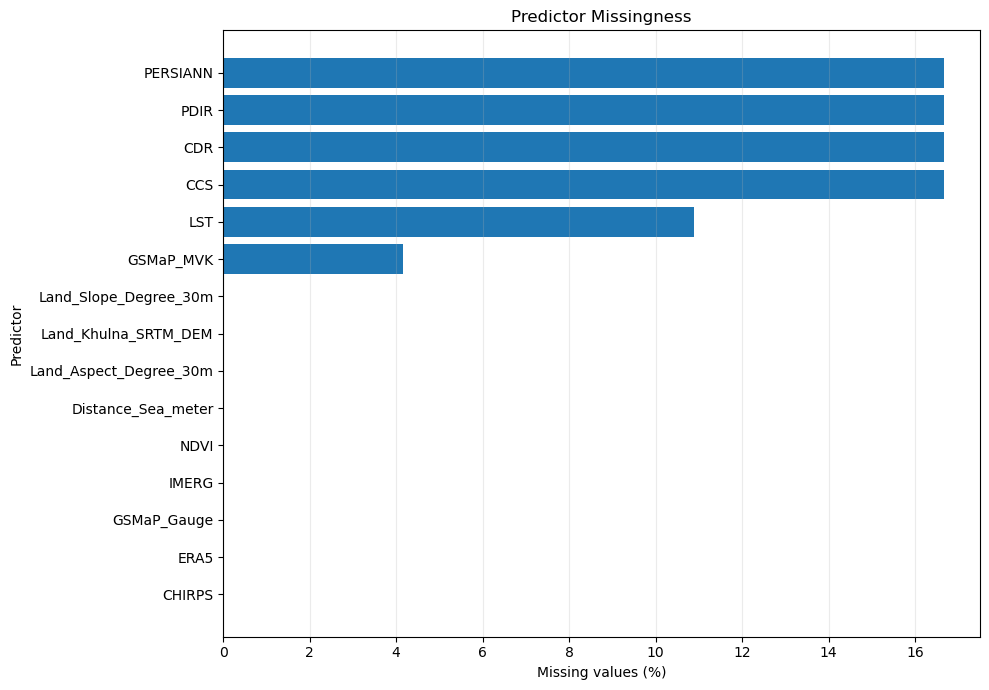

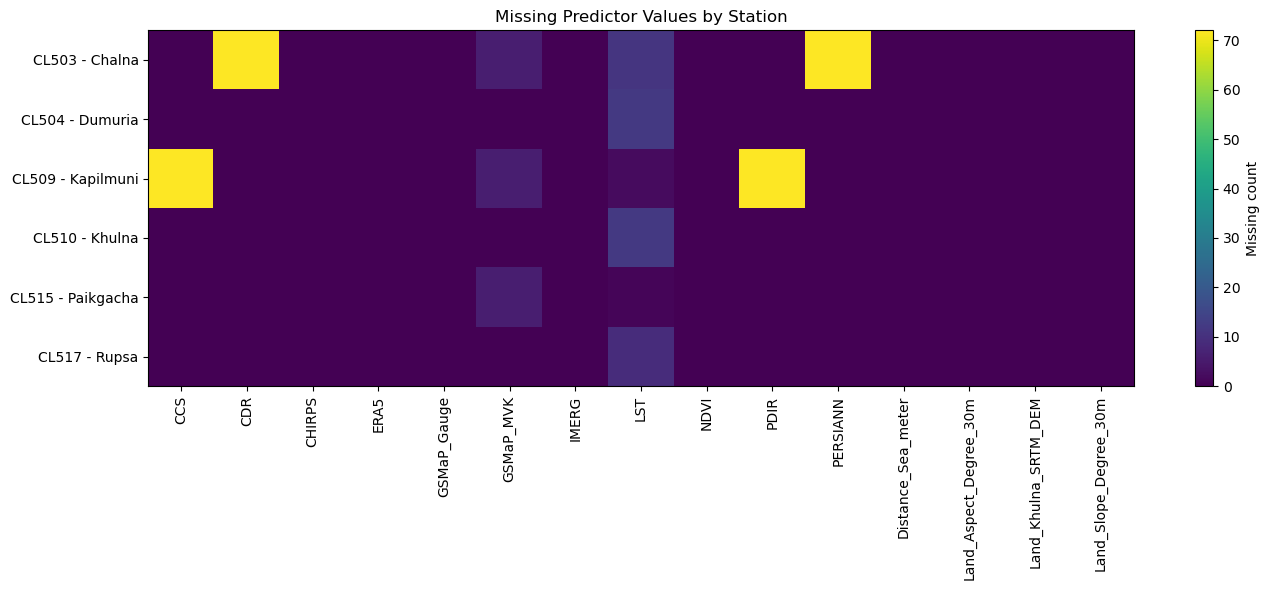

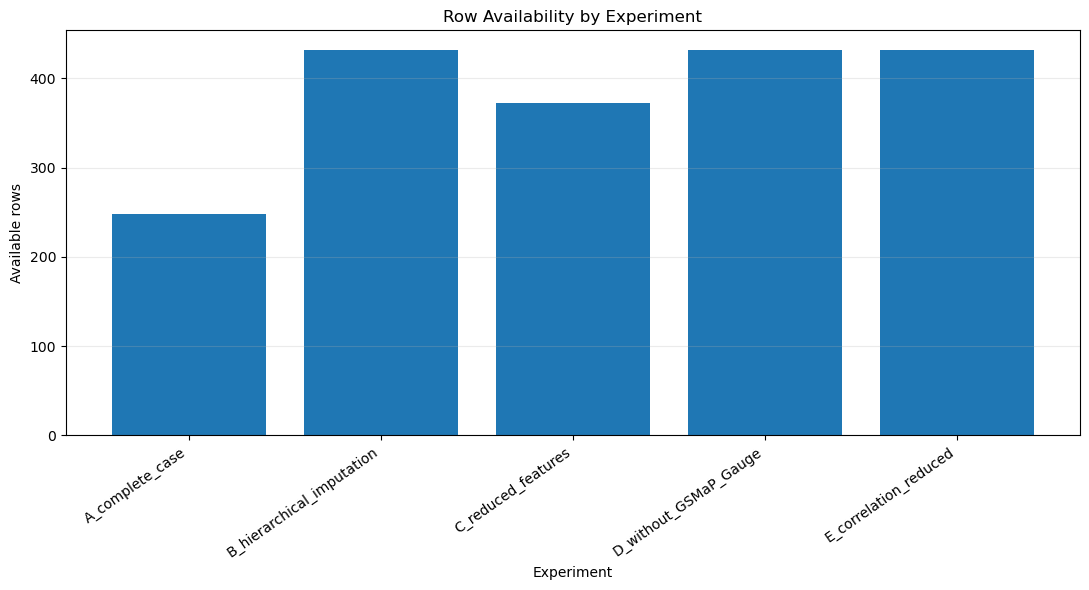

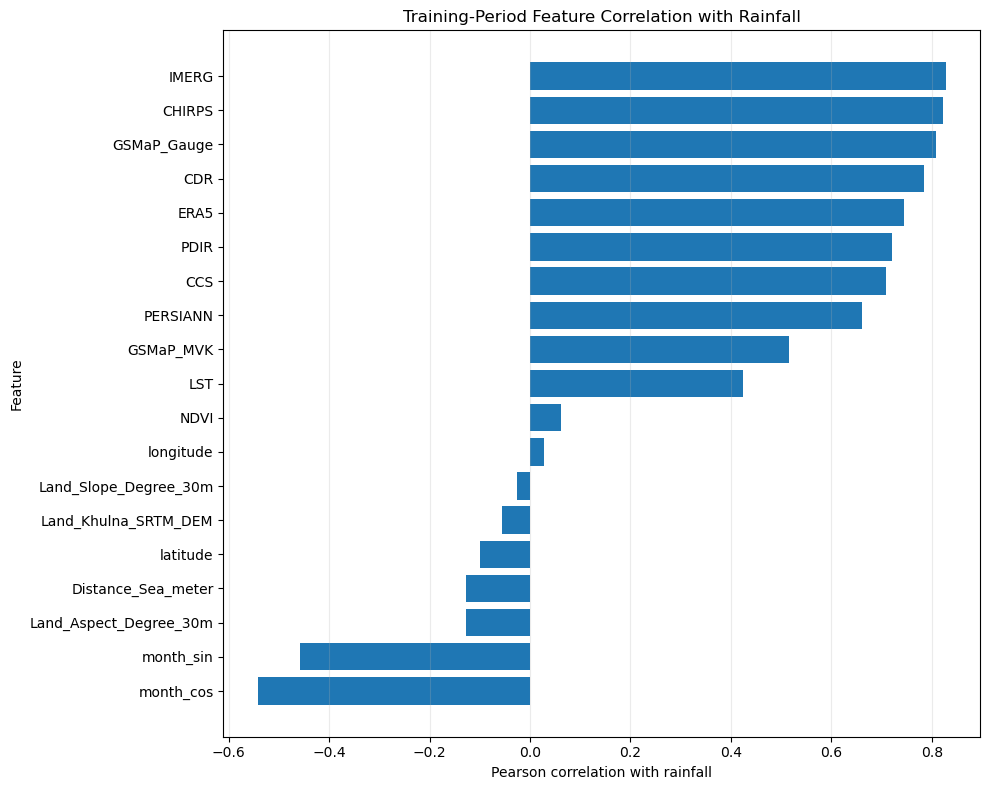


OUTPUT VERIFICATION
Experiment A file exists : True
Experiment B file exists : True
Experiment C file exists : True
Experiment D file exists : True
Experiment E file exists : True
GSMaP_Gauge absent from Experiment D: True
Experiment E feature count saved: 12

MISSING DATA AND FEATURE SELECTION COMPLETED
Input rows                    : 432
Train rows                    : 288
Validation rows               : 72
Test rows                     : 72
Complete-case rows            : 248
Imputed rows                  : 432
Reduced-feature rows          : 372
Without-GSMaP_Gauge rows      : 432
Correlation-reduced rows      : 432
Base feature count            : 19
Reduced feature count         : 15
Without GSMaP_Gauge features  : 18
Correlation-reduced features  : 12
Constant features removed     : []
Missing after imputation      : 0
Figures created               : 4

Recommended dataset for first model-training experiment:
E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khul

In [5]:
# ======================================================================
# 07_Missing_Data_and_Feature_Selection.ipynb
# COMPLETE CORRECTED VERSION
# ======================================================================
#
# Input:
#   data/processed/model_data/model_dataset_eda_ready.csv
#
# Temporal split:
#   Train      : 2017-2020
#   Validation : 2021
#   Test       : 2022
#
# Experiments:
#   A. Complete-case dataset
#   B. Hierarchically imputed full-feature dataset
#   C. Reduced-feature dataset
#   D. Dataset without GSMaP_Gauge
#   E. Correlation-reduced dataset
#
# Main recommended dataset:
#   recommended_training_dataset.csv
# ======================================================================


# ======================================================================
# 1. IMPORT LIBRARIES
# ======================================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


warnings.filterwarnings("ignore")


# ======================================================================
# 2. PROJECT CONFIGURATION
# ======================================================================

PROJECT_ROOT = Path(
    r"E:\Geospatial\Precipitation Downscaling"
    r"\Precipitation-Downscaling-Khulna"
)


INPUT_CSV = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "model_data"
    / "model_dataset_eda_ready.csv"
)


OUTPUT_FOLDER = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "model_data"
    / "feature_selection"
)


LOG_FOLDER = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "logs"
)


FIGURE_FOLDER = (
    PROJECT_ROOT
    / "figures"
    / "feature_selection"
)


OUTPUT_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

LOG_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


# ======================================================================
# 3. ANALYSIS SETTINGS
# ======================================================================

TARGET_COLUMN = "rainfall_mm"


TRAIN_YEARS = [
    2017,
    2018,
    2019,
    2020,
]


VALIDATION_YEARS = [
    2021,
]


TEST_YEARS = [
    2022,
]


EXPECTED_PREDICTORS = [
    "CCS",
    "CDR",
    "CHIRPS",
    "ERA5",
    "GSMaP_Gauge",
    "GSMaP_MVK",
    "IMERG",
    "LST",
    "NDVI",
    "PDIR",
    "PERSIANN",
    "Distance_Sea_meter",
    "Land_Aspect_Degree_30m",
    "Land_Khulna_SRTM_DEM",
    "Land_Slope_Degree_30m",
]


TEMPORAL_FEATURES = [
    "month_sin",
    "month_cos",
]


COORDINATE_FEATURES = [
    "latitude",
    "longitude",
]


METADATA_COLUMNS = [
    "station_id",
    "station_name",
    "latitude",
    "longitude",
    "year",
    "month",
    "date",
    "month_id",
    "season",
]


QUALITY_COLUMNS = [
    "raster_x",
    "raster_y",
    "inside_raster_bounds",
    "valid_predictor_count",
    "missing_predictor_count",
    "all_predictors_available",
]


# EDA অনুযায়ী comparatively high-missing predictors
MANUAL_REDUCED_FEATURE_EXCLUSIONS = [
    "CCS",
    "CDR",
    "PDIR",
    "PERSIANN",
]


HIGH_CORRELATION_THRESHOLD = 0.90

NEAR_CONSTANT_DOMINANT_RATIO = 0.95

CREATE_WITHOUT_GSMAP_GAUGE_EXPERIMENT = True

CREATE_CORRELATION_REDUCED_EXPERIMENT = True


# ======================================================================
# 4. HELPER FUNCTIONS
# ======================================================================

def save_figure(filename):
    """
    Save current matplotlib figure.
    """

    output_path = (
        FIGURE_FOLDER
        / filename
    )

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    return output_path


def classify_split(year):
    """
    Assign temporal split.
    """

    if year in TRAIN_YEARS:
        return "train"

    if year in VALIDATION_YEARS:
        return "validation"

    if year in TEST_YEARS:
        return "test"

    return "unused"


def convert_numeric_columns(
    dataframe,
    columns
):
    """
    Safely convert selected columns to numeric.
    """

    dataframe = dataframe.copy()

    for column in columns:

        if column in dataframe.columns:

            dataframe[column] = pd.to_numeric(
                dataframe[column],
                errors="coerce"
            )

    return dataframe


def feature_missing_summary(
    dataframe,
    features
):
    """
    Create predictor-wise missing-value summary.
    """

    records = []

    for feature in features:

        if feature not in dataframe.columns:
            continue

        missing_count = int(
            dataframe[
                feature
            ].isna().sum()
        )

        missing_percent = (
            missing_count
            / len(dataframe)
            * 100
            if len(dataframe) > 0
            else np.nan
        )

        if missing_percent >= 15:

            missing_category = "High"

        elif missing_percent >= 5:

            missing_category = "Moderate"

        elif missing_percent > 0:

            missing_category = "Low"

        else:

            missing_category = "None"


        records.append({
            "Feature": feature,
            "Valid_Count": int(
                dataframe[
                    feature
                ].notna().sum()
            ),
            "Missing_Count": missing_count,
            "Missing_Percent": round(
                missing_percent,
                4
            ),
            "Missing_Category": missing_category,
            "Unique_Values": int(
                dataframe[
                    feature
                ].nunique(
                    dropna=True
                )
            ),
        })


    return pd.DataFrame(
        records
    )


def detect_constant_features(
    dataframe,
    features
):
    """
    Detect constant and near-constant features.
    """

    records = []

    for feature in features:

        if feature not in dataframe.columns:
            continue

        series = dataframe[
            feature
        ].dropna()


        if series.empty:

            unique_values = 0
            dominant_ratio = np.nan
            constant = True
            near_constant = True

        else:

            unique_values = int(
                series.nunique()
            )

            value_frequencies = (
                series
                .value_counts(
                    normalize=True
                )
            )

            dominant_ratio = float(
                value_frequencies.iloc[0]
            )

            constant = (
                unique_values <= 1
            )

            near_constant = (
                constant
                or
                dominant_ratio
                >= NEAR_CONSTANT_DOMINANT_RATIO
            )


        records.append({
            "Feature": feature,
            "Unique_Values": unique_values,
            "Dominant_Ratio": dominant_ratio,
            "Constant": constant,
            "Near_Constant": near_constant,
        })


    return pd.DataFrame(
        records
    )


def get_high_correlation_pairs(
    dataframe,
    features,
    threshold=0.90
):
    """
    Return unique highly correlated feature pairs.
    """

    usable_features = [
        feature
        for feature in features
        if feature in dataframe.columns
        and dataframe[
            feature
        ].nunique(
            dropna=True
        ) > 1
    ]


    if len(usable_features) < 2:

        return pd.DataFrame(
            columns=[
                "Feature_1",
                "Feature_2",
                "Correlation",
                "Absolute_Correlation",
            ]
        )


    correlation_matrix = (
        dataframe[
            usable_features
        ]
        .corr(
            method="pearson"
        )
    )


    records = []


    for first_index in range(
        len(usable_features)
    ):

        for second_index in range(
            first_index + 1,
            len(usable_features)
        ):

            feature_1 = usable_features[
                first_index
            ]

            feature_2 = usable_features[
                second_index
            ]


            correlation_value = (
                correlation_matrix.loc[
                    feature_1,
                    feature_2
                ]
            )


            if pd.isna(
                correlation_value
            ):

                continue


            if abs(
                correlation_value
            ) >= threshold:

                records.append({
                    "Feature_1": feature_1,
                    "Feature_2": feature_2,
                    "Correlation": float(
                        correlation_value
                    ),
                    "Absolute_Correlation": float(
                        abs(
                            correlation_value
                        )
                    ),
                })


    if not records:

        return pd.DataFrame(
            columns=[
                "Feature_1",
                "Feature_2",
                "Correlation",
                "Absolute_Correlation",
            ]
        )


    return (
        pd.DataFrame(
            records
        )
        .sort_values(
            "Absolute_Correlation",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


def create_correlation_reduced_features(
    dataframe,
    features,
    target_column,
    threshold=0.90
):
    """
    Greedy correlation screening.

    Highly correlated pair-এর মধ্যে target-এর সঙ্গে বেশি absolute
    correlation থাকা feature রাখা হবে।
    """

    usable_features = [
        feature
        for feature in features
        if feature in dataframe.columns
        and dataframe[
            feature
        ].nunique(
            dropna=True
        ) > 1
    ]


    target_correlations = (
        dataframe[
            usable_features
            + [
                target_column
            ]
        ]
        .corr(
            method="pearson"
        )[
            target_column
        ]
        .drop(
            target_column
        )
        .abs()
        .fillna(0)
    )


    high_pair_df = (
        get_high_correlation_pairs(
            dataframe=dataframe,
            features=usable_features,
            threshold=threshold
        )
    )


    removed_features = set()

    decision_records = []


    for _, pair_row in (
        high_pair_df.iterrows()
    ):

        feature_1 = pair_row[
            "Feature_1"
        ]

        feature_2 = pair_row[
            "Feature_2"
        ]


        if (
            feature_1
            in removed_features
            or
            feature_2
            in removed_features
        ):

            continue


        target_score_1 = float(
            target_correlations.get(
                feature_1,
                0
            )
        )

        target_score_2 = float(
            target_correlations.get(
                feature_2,
                0
            )
        )


        if target_score_1 >= target_score_2:

            kept_feature = feature_1
            removed_feature = feature_2

        else:

            kept_feature = feature_2
            removed_feature = feature_1


        removed_features.add(
            removed_feature
        )


        decision_records.append({
            "Feature_1": feature_1,
            "Feature_2": feature_2,
            "Pair_Correlation": pair_row[
                "Correlation"
            ],
            "Target_Correlation_Feature_1": (
                target_score_1
            ),
            "Target_Correlation_Feature_2": (
                target_score_2
            ),
            "Kept_Feature": kept_feature,
            "Removed_Feature": removed_feature,
        })


    selected_features = [
        feature
        for feature in usable_features
        if feature
        not in removed_features
    ]


    return (
        selected_features,
        pd.DataFrame(
            decision_records
        )
    )


def fit_hierarchical_imputer(
    training_dataframe,
    features
):
    """
    Fit imputation statistics from training data only.

    Hierarchy:
        1. Station + month median
        2. Calendar-month median
        3. Global training median
    """

    station_month_medians = {}

    calendar_month_medians = {}

    global_medians = {}


    for feature in features:

        if feature not in training_dataframe.columns:
            continue


        station_month_medians[
            feature
        ] = (
            training_dataframe
            .groupby(
                [
                    "station_id",
                    "month"
                ]
            )[
                feature
            ]
            .median()
        )


        calendar_month_medians[
            feature
        ] = (
            training_dataframe
            .groupby(
                "month"
            )[
                feature
            ]
            .median()
        )


        global_medians[
            feature
        ] = (
            training_dataframe[
                feature
            ].median()
        )


    return {
        "station_month_medians":
            station_month_medians,

        "calendar_month_medians":
            calendar_month_medians,

        "global_medians":
            global_medians,
    }


def apply_hierarchical_imputer(
    dataframe,
    features,
    imputer
):
    """
    Apply training-derived imputation statistics.
    """

    output_dataframe = (
        dataframe.copy()
    )

    audit_records = []


    for feature in features:

        if feature not in output_dataframe.columns:
            continue


        original_missing_count = int(
            output_dataframe[
                feature
            ].isna().sum()
        )


        station_month_fill_count = 0

        calendar_month_fill_count = 0

        global_median_fill_count = 0


        # --------------------------------------------------------------
        # Stage 1: station + month median
        # --------------------------------------------------------------

        station_month_lookup = (
            imputer[
                "station_month_medians"
            ][
                feature
            ]
        )


        missing_indices = (
            output_dataframe.index[
                output_dataframe[
                    feature
                ].isna()
            ]
        )


        for row_index in missing_indices:

            lookup_key = (
                output_dataframe.at[
                    row_index,
                    "station_id"
                ],
                output_dataframe.at[
                    row_index,
                    "month"
                ]
            )


            if lookup_key in (
                station_month_lookup.index
            ):

                fill_value = (
                    station_month_lookup.loc[
                        lookup_key
                    ]
                )


                if pd.notna(
                    fill_value
                ):

                    output_dataframe.at[
                        row_index,
                        feature
                    ] = fill_value

                    station_month_fill_count += 1


        # --------------------------------------------------------------
        # Stage 2: calendar-month median
        # --------------------------------------------------------------

        calendar_month_lookup = (
            imputer[
                "calendar_month_medians"
            ][
                feature
            ]
        )


        missing_indices = (
            output_dataframe.index[
                output_dataframe[
                    feature
                ].isna()
            ]
        )


        for row_index in missing_indices:

            month_value = (
                output_dataframe.at[
                    row_index,
                    "month"
                ]
            )


            if month_value in (
                calendar_month_lookup.index
            ):

                fill_value = (
                    calendar_month_lookup.loc[
                        month_value
                    ]
                )


                if pd.notna(
                    fill_value
                ):

                    output_dataframe.at[
                        row_index,
                        feature
                    ] = fill_value

                    calendar_month_fill_count += 1


        # --------------------------------------------------------------
        # Stage 3: global training median
        # --------------------------------------------------------------

        global_median = (
            imputer[
                "global_medians"
            ][
                feature
            ]
        )


        if pd.notna(
            global_median
        ):

            remaining_missing_mask = (
                output_dataframe[
                    feature
                ].isna()
            )


            global_median_fill_count = int(
                remaining_missing_mask.sum()
            )


            output_dataframe.loc[
                remaining_missing_mask,
                feature
            ] = global_median


        audit_records.append({
            "Feature": feature,
            "Original_Missing": (
                original_missing_count
            ),
            "Filled_Station_Month": (
                station_month_fill_count
            ),
            "Filled_Calendar_Month": (
                calendar_month_fill_count
            ),
            "Filled_Global_Median": (
                global_median_fill_count
            ),
            "Remaining_Missing": int(
                output_dataframe[
                    feature
                ].isna().sum()
            ),
        })


    return (
        output_dataframe,
        pd.DataFrame(
            audit_records
        )
    )


def prepare_experiment_dataframe(
    source_dataframe,
    feature_columns
):
    """
    Keep only relevant metadata, target, selected features and QC columns.
    """

    output_columns = []


    for column in METADATA_COLUMNS:

        if (
            column in source_dataframe.columns
            and column not in output_columns
        ):

            output_columns.append(
                column
            )


    for column in [
        "split",
        TARGET_COLUMN
    ]:

        if (
            column in source_dataframe.columns
            and column not in output_columns
        ):

            output_columns.append(
                column
            )


    for column in feature_columns:

        if (
            column in source_dataframe.columns
            and column not in output_columns
        ):

            output_columns.append(
                column
            )


    for column in QUALITY_COLUMNS:

        if (
            column in source_dataframe.columns
            and column not in output_columns
        ):

            output_columns.append(
                column
            )


    output_dataframe = (
        source_dataframe[
            output_columns
        ]
        .copy()
        .sort_values(
            [
                "year",
                "month",
                "station_id"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    return output_dataframe


def create_experiment_summary_record(
    experiment_name,
    dataframe,
    feature_columns,
    notes
):
    """
    Create one experiment-comparison record.
    """

    if dataframe.empty:

        return {
            "Experiment": experiment_name,
            "Rows": 0,
            "Train_Rows": 0,
            "Validation_Rows": 0,
            "Test_Rows": 0,
            "Feature_Count": len(
                feature_columns
            ),
            "Missing_Feature_Values": np.nan,
            "Complete_Feature_Rows": 0,
            "Notes": notes,
        }


    missing_feature_values = int(
        dataframe[
            feature_columns
        ]
        .isna()
        .sum()
        .sum()
    )


    complete_feature_rows = int(
        dataframe[
            feature_columns
        ]
        .notna()
        .all(
            axis=1
        )
        .sum()
    )


    return {
        "Experiment": experiment_name,

        "Rows": len(
            dataframe
        ),

        "Train_Rows": int(
            (
                dataframe[
                    "split"
                ]
                == "train"
            ).sum()
        ),

        "Validation_Rows": int(
            (
                dataframe[
                    "split"
                ]
                == "validation"
            ).sum()
        ),

        "Test_Rows": int(
            (
                dataframe[
                    "split"
                ]
                == "test"
            ).sum()
        ),

        "Feature_Count": len(
            feature_columns
        ),

        "Missing_Feature_Values":
            missing_feature_values,

        "Complete_Feature_Rows":
            complete_feature_rows,

        "Notes": notes,
    }


# ======================================================================
# 5. INITIAL VALIDATION
# ======================================================================

print("=" * 86)
print("MISSING DATA TREATMENT AND FEATURE SELECTION")
print("=" * 86)

print(
    f"Project root  : "
    f"{PROJECT_ROOT}"
)

print(
    f"Input CSV     : "
    f"{INPUT_CSV}"
)

print(
    f"Output folder : "
    f"{OUTPUT_FOLDER}"
)

print(
    f"Log folder    : "
    f"{LOG_FOLDER}"
)

print(
    f"Figure folder : "
    f"{FIGURE_FOLDER}"
)

print()


if not PROJECT_ROOT.exists():

    raise FileNotFoundError(
        f"Project root পাওয়া যায়নি:\n"
        f"{PROJECT_ROOT}"
    )


if not INPUT_CSV.exists():

    raise FileNotFoundError(
        f"Input dataset পাওয়া যায়নি:\n"
        f"{INPUT_CSV}"
    )


# ======================================================================
# 6. LOAD DATASET
# ======================================================================

df = pd.read_csv(
    INPUT_CSV
)


print(
    f"Input rows    : "
    f"{len(df)}"
)

print(
    f"Input columns : "
    f"{len(df.columns)}"
)


required_columns = [
    "station_id",
    "station_name",
    "latitude",
    "longitude",
    "year",
    "month",
    TARGET_COLUMN,
]


missing_required_columns = [
    column
    for column in required_columns
    if column not in df.columns
]


if missing_required_columns:

    raise ValueError(
        "Required columns missing:\n"
        + ", ".join(
            missing_required_columns
        )
    )


numeric_columns = (
    EXPECTED_PREDICTORS
    + TEMPORAL_FEATURES
    + COORDINATE_FEATURES
    + [
        TARGET_COLUMN,
        "year",
        "month",
        "raster_x",
        "raster_y",
        "valid_predictor_count",
        "missing_predictor_count",
    ]
)


df = convert_numeric_columns(
    dataframe=df,
    columns=numeric_columns
)


if "date" in df.columns:

    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )


df["year"] = (
    df["year"]
    .astype(int)
)


df["month"] = (
    df["month"]
    .astype(int)
)


df["split"] = (
    df["year"]
    .apply(
        classify_split
    )
)


unused_rows = int(
    (
        df[
            "split"
        ]
        == "unused"
    ).sum()
)


if unused_rows > 0:

    print(
        f"WARNING: {unused_rows} rows "
        f"configured period-এর বাইরে।"
    )


df = df[
    df[
        "split"
    ]
    != "unused"
].copy()


duplicate_count = int(
    df.duplicated(
        subset=[
            "station_id",
            "year",
            "month"
        ]
    ).sum()
)


if duplicate_count > 0:

    raise ValueError(
        f"{duplicate_count}টি duplicate "
        f"station-month row পাওয়া গেছে।"
    )


available_predictors = [
    predictor
    for predictor in EXPECTED_PREDICTORS
    if predictor in df.columns
]


missing_expected_predictors = [
    predictor
    for predictor in EXPECTED_PREDICTORS
    if predictor not in df.columns
]


available_temporal_features = [
    feature
    for feature in TEMPORAL_FEATURES
    if feature in df.columns
]


available_coordinate_features = [
    feature
    for feature in COORDINATE_FEATURES
    if feature in df.columns
]


all_candidate_features = (
    available_predictors
    + available_temporal_features
    + available_coordinate_features
)


print()
print(
    f"Available raster predictors : "
    f"{len(available_predictors)}"
)

print(
    f"Temporal features           : "
    f"{len(available_temporal_features)}"
)

print(
    f"Coordinate features         : "
    f"{len(available_coordinate_features)}"
)

print(
    f"Total candidate features    : "
    f"{len(all_candidate_features)}"
)


if missing_expected_predictors:

    print()
    print(
        "Missing expected predictors:"
    )

    for predictor in (
        missing_expected_predictors
    ):

        print(
            f"  {predictor}"
        )


# ======================================================================
# 7. TEMPORAL SPLIT
# ======================================================================

train_df = df[
    df[
        "split"
    ]
    == "train"
].copy()


validation_df = df[
    df[
        "split"
    ]
    == "validation"
].copy()


test_df = df[
    df[
        "split"
    ]
    == "test"
].copy()


split_summary_df = (
    df
    .groupby(
        "split",
        as_index=False
    )
    .agg(
        rows=(
            TARGET_COLUMN,
            "size"
        ),
        stations=(
            "station_id",
            "nunique"
        ),
        start_year=(
            "year",
            "min"
        ),
        end_year=(
            "year",
            "max"
        ),
        valid_target=(
            TARGET_COLUMN,
            "count"
        ),
    )
)


split_order_map = {
    "train": 1,
    "validation": 2,
    "test": 3,
}


split_summary_df[
    "sort_order"
] = (
    split_summary_df[
        "split"
    ]
    .map(
        split_order_map
    )
)


split_summary_df = (
    split_summary_df
    .sort_values(
        "sort_order"
    )
    .drop(
        columns=[
            "sort_order"
        ]
    )
    .reset_index(
        drop=True
    )
)


print()
print("=" * 86)
print("TEMPORAL SPLIT SUMMARY")
print("=" * 86)

display(
    split_summary_df
)


# ======================================================================
# 8. MISSING VALUE DIAGNOSIS
# ======================================================================

missing_summary_df = (
    feature_missing_summary(
        dataframe=df,
        features=available_predictors
    )
)


missing_by_station_df = (
    df
    .groupby(
        [
            "station_id",
            "station_name"
        ]
    )[
        available_predictors
    ]
    .agg(
        lambda series:
        int(
            series.isna().sum()
        )
    )
    .reset_index()
)


missing_by_year_month_df = (
    df
    .groupby(
        [
            "year",
            "month"
        ]
    )[
        available_predictors
    ]
    .agg(
        lambda series:
        int(
            series.isna().sum()
        )
    )
    .reset_index()
)


missing_by_calendar_month_df = (
    df
    .groupby(
        "month"
    )[
        available_predictors
    ]
    .agg(
        lambda series:
        int(
            series.isna().sum()
        )
    )
    .reset_index()
)


missing_by_split_df = (
    df
    .groupby(
        "split"
    )[
        available_predictors
    ]
    .agg(
        lambda series:
        int(
            series.isna().sum()
        )
    )
    .reset_index()
)


complete_predictor_rows = int(
    df[
        available_predictors
    ]
    .notna()
    .all(
        axis=1
    )
    .sum()
)


rows_with_missing_predictor = int(
    df[
        available_predictors
    ]
    .isna()
    .any(
        axis=1
    )
    .sum()
)


print()
print("=" * 86)
print("FEATURE MISSINGNESS SUMMARY")
print("=" * 86)

display(
    missing_summary_df
)


print(
    f"Complete predictor rows     : "
    f"{complete_predictor_rows}"
)

print(
    f"Rows with missing predictor : "
    f"{rows_with_missing_predictor}"
)


# ======================================================================
# 9. CONSTANT FEATURE SCREENING
# ======================================================================

constant_summary_df = (
    detect_constant_features(
        dataframe=train_df,
        features=all_candidate_features
    )
)


constant_features = (
    constant_summary_df[
        constant_summary_df[
            "Constant"
        ]
    ][
        "Feature"
    ]
    .tolist()
)


near_constant_features = (
    constant_summary_df[
        constant_summary_df[
            "Near_Constant"
        ]
    ][
        "Feature"
    ]
    .tolist()
)


base_features = [
    feature
    for feature in all_candidate_features
    if feature not in constant_features
]


print()
print("=" * 86)
print("CONSTANT FEATURE SCREENING")
print("=" * 86)

display(
    constant_summary_df
)


print(
    f"Constant features removed : "
    f"{constant_features}"
)

print(
    f"Near-constant features    : "
    f"{near_constant_features}"
)


# ======================================================================
# 10. HIGH-CORRELATION SCREENING
# ======================================================================

high_correlation_pairs_df = (
    get_high_correlation_pairs(
        dataframe=train_df,
        features=base_features,
        threshold=(
            HIGH_CORRELATION_THRESHOLD
        )
    )
)


if CREATE_CORRELATION_REDUCED_EXPERIMENT:

    (
        correlation_reduced_features,
        correlation_decisions_df
    ) = (
        create_correlation_reduced_features(
            dataframe=train_df,
            features=base_features,
            target_column=TARGET_COLUMN,
            threshold=(
                HIGH_CORRELATION_THRESHOLD
            )
        )
    )

else:

    correlation_reduced_features = (
        base_features.copy()
    )

    correlation_decisions_df = (
        pd.DataFrame()
    )


print()
print("=" * 86)
print(
    "HIGH-CORRELATION PAIRS "
    f"(|r| >= {HIGH_CORRELATION_THRESHOLD})"
)
print("=" * 86)

display(
    high_correlation_pairs_df
)


print()
print(
    f"Base feature count               : "
    f"{len(base_features)}"
)

print(
    f"Correlation-reduced feature count: "
    f"{len(correlation_reduced_features)}"
)


# ======================================================================
# 11. EXPERIMENT A: COMPLETE CASE
# ======================================================================

experiment_A_source_df = (
    df.dropna(
        subset=(
            base_features
            + [
                TARGET_COLUMN
            ]
        )
    )
    .copy()
)


experiment_A_df = (
    prepare_experiment_dataframe(
        source_dataframe=(
            experiment_A_source_df
        ),
        feature_columns=(
            base_features
        )
    )
)


# ======================================================================
# 12. EXPERIMENT B: HIERARCHICAL IMPUTATION
# ======================================================================

hierarchical_imputer = (
    fit_hierarchical_imputer(
        training_dataframe=train_df,
        features=base_features
    )
)


(
    train_imputed_df,
    train_imputation_audit_df
) = apply_hierarchical_imputer(
    dataframe=train_df,
    features=base_features,
    imputer=hierarchical_imputer
)


(
    validation_imputed_df,
    validation_imputation_audit_df
) = apply_hierarchical_imputer(
    dataframe=validation_df,
    features=base_features,
    imputer=hierarchical_imputer
)


(
    test_imputed_df,
    test_imputation_audit_df
) = apply_hierarchical_imputer(
    dataframe=test_df,
    features=base_features,
    imputer=hierarchical_imputer
)


train_imputation_audit_df[
    "Split"
] = "train"


validation_imputation_audit_df[
    "Split"
] = "validation"


test_imputation_audit_df[
    "Split"
] = "test"


imputation_audit_df = (
    pd.concat(
        [
            train_imputation_audit_df,
            validation_imputation_audit_df,
            test_imputation_audit_df,
        ],
        ignore_index=True
    )
)


imputed_full_df = (
    pd.concat(
        [
            train_imputed_df,
            validation_imputed_df,
            test_imputed_df,
        ],
        ignore_index=True
    )
)


experiment_B_df = (
    prepare_experiment_dataframe(
        source_dataframe=(
            imputed_full_df
        ),
        feature_columns=(
            base_features
        )
    )
)


remaining_missing_after_imputation = int(
    experiment_B_df[
        base_features
    ]
    .isna()
    .sum()
    .sum()
)


if remaining_missing_after_imputation > 0:

    raise RuntimeError(
        f"Imputation-এর পরও "
        f"{remaining_missing_after_imputation}টি "
        f"missing feature value আছে।"
    )


# ======================================================================
# 13. EXPERIMENT C: REDUCED FEATURES
# ======================================================================

reduced_features = [
    feature
    for feature in base_features
    if feature not in (
        MANUAL_REDUCED_FEATURE_EXCLUSIONS
    )
]


experiment_C_source_df = (
    df.dropna(
        subset=(
            reduced_features
            + [
                TARGET_COLUMN
            ]
        )
    )
    .copy()
)


experiment_C_df = (
    prepare_experiment_dataframe(
        source_dataframe=(
            experiment_C_source_df
        ),
        feature_columns=(
            reduced_features
        )
    )
)


# ======================================================================
# 14. EXPERIMENT D: WITHOUT GSMaP_Gauge
# ======================================================================

without_gsmap_gauge_features = [
    feature
    for feature in base_features
    if feature != "GSMaP_Gauge"
]


if CREATE_WITHOUT_GSMAP_GAUGE_EXPERIMENT:

    experiment_D_df = (
        prepare_experiment_dataframe(
            source_dataframe=(
                imputed_full_df
            ),
            feature_columns=(
                without_gsmap_gauge_features
            )
        )
    )

else:

    experiment_D_df = (
        pd.DataFrame()
    )


# Confirm GSMaP_Gauge is truly absent
if (
    CREATE_WITHOUT_GSMAP_GAUGE_EXPERIMENT
    and
    "GSMaP_Gauge"
    in experiment_D_df.columns
):

    raise RuntimeError(
        "Experiment D-তে GSMaP_Gauge "
        "ভুলভাবে থেকে গেছে।"
    )


# ======================================================================
# 15. EXPERIMENT E: CORRELATION-REDUCED FEATURES
# ======================================================================

if CREATE_CORRELATION_REDUCED_EXPERIMENT:

    experiment_E_df = (
        prepare_experiment_dataframe(
            source_dataframe=(
                imputed_full_df
            ),
            feature_columns=(
                correlation_reduced_features
            )
        )
    )

else:

    experiment_E_df = (
        pd.DataFrame()
    )


# ======================================================================
# 16. TARGET CORRELATION SUMMARY
# ======================================================================

target_correlation_records = []


for feature in base_features:

    pearson_correlation = (
        train_imputed_df[
            [
                feature,
                TARGET_COLUMN
            ]
        ]
        .corr(
            method="pearson"
        )
        .iloc[
            0,
            1
        ]
    )


    spearman_correlation = (
        train_imputed_df[
            [
                feature,
                TARGET_COLUMN
            ]
        ]
        .corr(
            method="spearman"
        )
        .iloc[
            0,
            1
        ]
    )


    target_correlation_records.append({
        "Feature": feature,
        "Pearson_Correlation": (
            pearson_correlation
        ),
        "Spearman_Correlation": (
            spearman_correlation
        ),
        "Absolute_Pearson": (
            abs(
                pearson_correlation
            )
            if pd.notna(
                pearson_correlation
            )
            else np.nan
        ),
    })


target_correlation_df = (
    pd.DataFrame(
        target_correlation_records
    )
    .sort_values(
        "Absolute_Pearson",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ======================================================================
# 17. EXPERIMENT COMPARISON
# ======================================================================

experiment_summary_records = []


experiment_summary_records.append(
    create_experiment_summary_record(
        experiment_name=(
            "A_complete_case"
        ),
        dataframe=(
            experiment_A_df
        ),
        feature_columns=(
            base_features
        ),
        notes=(
            "Rows with any missing candidate "
            "feature are removed."
        )
    )
)


experiment_summary_records.append(
    create_experiment_summary_record(
        experiment_name=(
            "B_hierarchical_imputation"
        ),
        dataframe=(
            experiment_B_df
        ),
        feature_columns=(
            base_features
        ),
        notes=(
            "Training-only station-month, "
            "calendar-month and global-median "
            "imputation."
        )
    )
)


experiment_summary_records.append(
    create_experiment_summary_record(
        experiment_name=(
            "C_reduced_features"
        ),
        dataframe=(
            experiment_C_df
        ),
        feature_columns=(
            reduced_features
        ),
        notes=(
            "CCS, CDR, PDIR and PERSIANN "
            "excluded because of high missingness."
        )
    )
)


experiment_summary_records.append(
    create_experiment_summary_record(
        experiment_name=(
            "D_without_GSMaP_Gauge"
        ),
        dataframe=(
            experiment_D_df
        ),
        feature_columns=(
            without_gsmap_gauge_features
        ),
        notes=(
            "Sensitivity experiment without "
            "gauge-adjusted GSMaP_Gauge predictor."
        )
    )
)


experiment_summary_records.append(
    create_experiment_summary_record(
        experiment_name=(
            "E_correlation_reduced"
        ),
        dataframe=(
            experiment_E_df
        ),
        feature_columns=(
            correlation_reduced_features
        ),
        notes=(
            "Imputed dataset with highly "
            "correlated predictors reduced."
        )
    )
)


experiment_summary_df = (
    pd.DataFrame(
        experiment_summary_records
    )
)


print()
print("=" * 86)
print("EXPERIMENT COMPARISON")
print("=" * 86)

display(
    experiment_summary_df
)


# ======================================================================
# 18. FEATURE SET DEFINITIONS
# ======================================================================

feature_sets = {
    "base_features":
        base_features,

    "experiment_A_complete_case":
        base_features,

    "experiment_B_hierarchical_imputation":
        base_features,

    "experiment_C_reduced_features":
        reduced_features,

    "experiment_D_without_GSMaP_Gauge":
        without_gsmap_gauge_features,

    "experiment_E_correlation_reduced":
        correlation_reduced_features,

    "constant_features_removed":
        constant_features,

    "near_constant_features":
        near_constant_features,

    "manual_reduced_feature_exclusions":
        MANUAL_REDUCED_FEATURE_EXCLUSIONS,
}


feature_set_records = []


for feature_set_name, feature_list in (
    feature_sets.items()
):

    for feature_order, feature in enumerate(
        feature_list,
        start=1
    ):

        feature_set_records.append({
            "Feature_Set": feature_set_name,
            "Order": feature_order,
            "Feature": feature,
        })


feature_sets_df = (
    pd.DataFrame(
        feature_set_records
    )
)


# ======================================================================
# 19. QUALITY VALIDATION
# ======================================================================

expected_total_rows = len(
    df
)


if len(
    experiment_B_df
) != expected_total_rows:

    raise RuntimeError(
        "Experiment B row count "
        f"{len(experiment_B_df)} != "
        f"{expected_total_rows}"
    )


if int(
    experiment_B_df[
        base_features
    ]
    .isna()
    .sum()
    .sum()
) > 0:

    raise RuntimeError(
        "Experiment B dataset-এ "
        "missing feature রয়েছে।"
    )


if int(
    experiment_B_df[
        TARGET_COLUMN
    ]
    .isna()
    .sum()
) > 0:

    raise RuntimeError(
        "Experiment B dataset-এ "
        "missing target রয়েছে।"
    )


for experiment_name, experiment_dataframe in [
    (
        "Experiment A",
        experiment_A_df
    ),
    (
        "Experiment B",
        experiment_B_df
    ),
    (
        "Experiment C",
        experiment_C_df
    ),
    (
        "Experiment D",
        experiment_D_df
    ),
    (
        "Experiment E",
        experiment_E_df
    ),
]:

    if experiment_dataframe.empty:
        continue


    duplicate_rows = int(
        experiment_dataframe.duplicated(
            subset=[
                "station_id",
                "year",
                "month"
            ]
        ).sum()
    )


    if duplicate_rows > 0:

        raise RuntimeError(
            f"{experiment_name}-এ "
            f"{duplicate_rows} duplicate row আছে।"
        )


# ======================================================================
# 20. CREATE FIGURES
# ======================================================================

created_figures = []


# ----------------------------------------------------------------------
# Missing-value percentage
# ----------------------------------------------------------------------

missing_plot_df = (
    missing_summary_df
    .sort_values(
        "Missing_Percent",
        ascending=True
    )
)


plt.figure(
    figsize=(
        10,
        7
    )
)


plt.barh(
    missing_plot_df[
        "Feature"
    ],
    missing_plot_df[
        "Missing_Percent"
    ]
)


plt.xlabel(
    "Missing values (%)"
)

plt.ylabel(
    "Predictor"
)

plt.title(
    "Predictor Missingness"
)

plt.grid(
    axis="x",
    alpha=0.25
)


created_figures.append(
    save_figure(
        "01_predictor_missingness.png"
    )
)


# ----------------------------------------------------------------------
# Missing values by station
# ----------------------------------------------------------------------

station_missing_matrix = (
    missing_by_station_df
    .set_index(
        [
            "station_id",
            "station_name"
        ]
    )[
        available_predictors
    ]
)


plt.figure(
    figsize=(
        14,
        6
    )
)


station_image = plt.imshow(
    station_missing_matrix.values,
    aspect="auto"
)


plt.colorbar(
    station_image,
    label="Missing count"
)


plt.xticks(
    ticks=np.arange(
        len(
            station_missing_matrix.columns
        )
    ),
    labels=(
        station_missing_matrix.columns
    ),
    rotation=90
)


plt.yticks(
    ticks=np.arange(
        len(
            station_missing_matrix.index
        )
    ),
    labels=[
        f"{station_id} - {station_name}"
        for station_id, station_name
        in station_missing_matrix.index
    ]
)


plt.title(
    "Missing Predictor Values by Station"
)


created_figures.append(
    save_figure(
        "02_missing_by_station.png"
    )
)


# ----------------------------------------------------------------------
# Experiment row comparison
# ----------------------------------------------------------------------

plt.figure(
    figsize=(
        11,
        6
    )
)


plt.bar(
    experiment_summary_df[
        "Experiment"
    ],
    experiment_summary_df[
        "Rows"
    ]
)


plt.xlabel(
    "Experiment"
)

plt.ylabel(
    "Available rows"
)

plt.title(
    "Row Availability by Experiment"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)


created_figures.append(
    save_figure(
        "03_experiment_row_comparison.png"
    )
)


# ----------------------------------------------------------------------
# Training-period target correlations
# ----------------------------------------------------------------------

target_plot_df = (
    target_correlation_df
    .sort_values(
        "Pearson_Correlation"
    )
)


plt.figure(
    figsize=(
        10,
        8
    )
)


plt.barh(
    target_plot_df[
        "Feature"
    ],
    target_plot_df[
        "Pearson_Correlation"
    ]
)


plt.xlabel(
    "Pearson correlation with rainfall"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Training-Period Feature Correlation with Rainfall"
)

plt.grid(
    axis="x",
    alpha=0.25
)


created_figures.append(
    save_figure(
        "04_training_feature_target_correlation.png"
    )
)


# ======================================================================
# 21. OUTPUT PATHS
# ======================================================================

EXPERIMENT_A_OUTPUT = (
    OUTPUT_FOLDER
    / "experiment_A_complete_case.csv"
)


EXPERIMENT_B_OUTPUT = (
    OUTPUT_FOLDER
    / "experiment_B_hierarchical_imputation.csv"
)


EXPERIMENT_C_OUTPUT = (
    OUTPUT_FOLDER
    / "experiment_C_reduced_features.csv"
)


EXPERIMENT_D_OUTPUT = (
    OUTPUT_FOLDER
    / "experiment_D_without_GSMaP_Gauge.csv"
)


EXPERIMENT_E_OUTPUT = (
    OUTPUT_FOLDER
    / "experiment_E_correlation_reduced.csv"
)


RECOMMENDED_TRAINING_OUTPUT = (
    OUTPUT_FOLDER
    / "recommended_training_dataset.csv"
)


MISSING_SUMMARY_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_missing_summary.csv"
)


MISSING_BY_STATION_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_missing_by_station.csv"
)


MISSING_BY_YEAR_MONTH_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_missing_by_year_month.csv"
)


MISSING_BY_CALENDAR_MONTH_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_missing_by_calendar_month.csv"
)


MISSING_BY_SPLIT_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_missing_by_split.csv"
)


CONSTANT_SUMMARY_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_constant_summary.csv"
)


HIGH_CORRELATION_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_high_correlation_pairs.csv"
)


CORRELATION_DECISIONS_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_correlation_decisions.csv"
)


IMPUTATION_AUDIT_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_imputation_audit.csv"
)


TARGET_CORRELATION_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_target_correlation.csv"
)


EXPERIMENT_SUMMARY_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_experiment_summary.csv"
)


FEATURE_SETS_CSV_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_feature_sets.csv"
)


FEATURE_SETS_JSON_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_feature_sets.json"
)


RECOMMENDED_FEATURES_OUTPUT = (
    LOG_FOLDER
    / "recommended_training_features.csv"
)


SPLIT_SUMMARY_OUTPUT = (
    LOG_FOLDER
    / "feature_selection_split_summary.csv"
)


# ======================================================================
# 22. SAVE OUTPUTS
# ======================================================================

experiment_A_df.to_csv(
    EXPERIMENT_A_OUTPUT,
    index=False
)


experiment_B_df.to_csv(
    EXPERIMENT_B_OUTPUT,
    index=False
)


experiment_C_df.to_csv(
    EXPERIMENT_C_OUTPUT,
    index=False
)


if (
    CREATE_WITHOUT_GSMAP_GAUGE_EXPERIMENT
):

    experiment_D_df.to_csv(
        EXPERIMENT_D_OUTPUT,
        index=False
    )


if (
    CREATE_CORRELATION_REDUCED_EXPERIMENT
):

    experiment_E_df.to_csv(
        EXPERIMENT_E_OUTPUT,
        index=False
    )


# Tree-based model-এর first experiment-এর জন্য recommended
experiment_B_df.to_csv(
    RECOMMENDED_TRAINING_OUTPUT,
    index=False
)


missing_summary_df.to_csv(
    MISSING_SUMMARY_OUTPUT,
    index=False
)


missing_by_station_df.to_csv(
    MISSING_BY_STATION_OUTPUT,
    index=False
)


missing_by_year_month_df.to_csv(
    MISSING_BY_YEAR_MONTH_OUTPUT,
    index=False
)


missing_by_calendar_month_df.to_csv(
    MISSING_BY_CALENDAR_MONTH_OUTPUT,
    index=False
)


missing_by_split_df.to_csv(
    MISSING_BY_SPLIT_OUTPUT,
    index=False
)


constant_summary_df.to_csv(
    CONSTANT_SUMMARY_OUTPUT,
    index=False
)


high_correlation_pairs_df.to_csv(
    HIGH_CORRELATION_OUTPUT,
    index=False
)


correlation_decisions_df.to_csv(
    CORRELATION_DECISIONS_OUTPUT,
    index=False
)


imputation_audit_df.to_csv(
    IMPUTATION_AUDIT_OUTPUT,
    index=False
)


target_correlation_df.to_csv(
    TARGET_CORRELATION_OUTPUT,
    index=False
)


experiment_summary_df.to_csv(
    EXPERIMENT_SUMMARY_OUTPUT,
    index=False
)


feature_sets_df.to_csv(
    FEATURE_SETS_CSV_OUTPUT,
    index=False
)


pd.DataFrame({
    "Feature": base_features
}).to_csv(
    RECOMMENDED_FEATURES_OUTPUT,
    index=False
)


split_summary_df.to_csv(
    SPLIT_SUMMARY_OUTPUT,
    index=False
)


with open(
    FEATURE_SETS_JSON_OUTPUT,
    "w",
    encoding="utf-8"
) as json_file:

    json.dump(
        feature_sets,
        json_file,
        indent=2,
        ensure_ascii=False
    )


# ======================================================================
# 23. FINAL OUTPUT VERIFICATION
# ======================================================================

print()
print("=" * 86)
print("OUTPUT VERIFICATION")
print("=" * 86)


print(
    f"Experiment A file exists : "
    f"{EXPERIMENT_A_OUTPUT.exists()}"
)

print(
    f"Experiment B file exists : "
    f"{EXPERIMENT_B_OUTPUT.exists()}"
)

print(
    f"Experiment C file exists : "
    f"{EXPERIMENT_C_OUTPUT.exists()}"
)

print(
    f"Experiment D file exists : "
    f"{EXPERIMENT_D_OUTPUT.exists()}"
)

print(
    f"Experiment E file exists : "
    f"{EXPERIMENT_E_OUTPUT.exists()}"
)


if EXPERIMENT_D_OUTPUT.exists():

    experiment_D_check_df = pd.read_csv(
        EXPERIMENT_D_OUTPUT,
        nrows=2
    )

    print(
        f"GSMaP_Gauge absent from "
        f"Experiment D: "
        f"{'GSMaP_Gauge' not in experiment_D_check_df.columns}"
    )


if EXPERIMENT_E_OUTPUT.exists():

    experiment_E_check_df = pd.read_csv(
        EXPERIMENT_E_OUTPUT,
        nrows=2
    )

    found_experiment_E_features = [
        feature
        for feature in correlation_reduced_features
        if feature in (
            experiment_E_check_df.columns
        )
    ]

    print(
        f"Experiment E feature count saved: "
        f"{len(found_experiment_E_features)}"
    )


# ======================================================================
# 24. FINAL COMPLETION MESSAGE
# ======================================================================

print()
print("=" * 86)
print(
    "MISSING DATA AND FEATURE SELECTION COMPLETED"
)
print("=" * 86)


print(
    f"Input rows                    : "
    f"{len(df)}"
)

print(
    f"Train rows                    : "
    f"{len(train_df)}"
)

print(
    f"Validation rows               : "
    f"{len(validation_df)}"
)

print(
    f"Test rows                     : "
    f"{len(test_df)}"
)

print(
    f"Complete-case rows            : "
    f"{len(experiment_A_df)}"
)

print(
    f"Imputed rows                  : "
    f"{len(experiment_B_df)}"
)

print(
    f"Reduced-feature rows          : "
    f"{len(experiment_C_df)}"
)

print(
    f"Without-GSMaP_Gauge rows      : "
    f"{len(experiment_D_df)}"
)

print(
    f"Correlation-reduced rows      : "
    f"{len(experiment_E_df)}"
)

print(
    f"Base feature count            : "
    f"{len(base_features)}"
)

print(
    f"Reduced feature count         : "
    f"{len(reduced_features)}"
)

print(
    f"Without GSMaP_Gauge features  : "
    f"{len(without_gsmap_gauge_features)}"
)

print(
    f"Correlation-reduced features  : "
    f"{len(correlation_reduced_features)}"
)

print(
    f"Constant features removed     : "
    f"{constant_features}"
)

print(
    f"Missing after imputation      : "
    f"{remaining_missing_after_imputation}"
)

print(
    f"Figures created               : "
    f"{len(created_figures)}"
)


print()
print(
    "Recommended dataset for first model-training experiment:"
)

print(
    RECOMMENDED_TRAINING_OUTPUT
)


print()
print(
    "Recommended base feature list:"
)


for feature_number, feature in enumerate(
    base_features,
    start=1
):

    print(
        f"{feature_number:02d}. "
        f"{feature}"
    )


print()
print("Main experiment outputs:")

print(
    f"1. {EXPERIMENT_A_OUTPUT}"
)

print(
    f"2. {EXPERIMENT_B_OUTPUT}"
)

print(
    f"3. {EXPERIMENT_C_OUTPUT}"
)

print(
    f"4. {EXPERIMENT_D_OUTPUT}"
)

print(
    f"5. {EXPERIMENT_E_OUTPUT}"
)


print()
print("Feature definitions:")

print(
    FEATURE_SETS_JSON_OUTPUT
)